In [1]:
import pathlib
from datetime import datetime, timedelta
from functools import partial

import numpy as np
import pandas as pd
import xarray as xr
import torch

from matplotlib import pyplot as plt
from torchvision.ops import MLP


In [2]:
data_path = pathlib.Path("../data/goes_cloudsat_merged/")
files = sorted(list(data_path.glob("*.nc")))
len(files)

100

In [3]:
dt = xr.open_datatree(files[0])

In [4]:
dt

<xarray.DataTree>
Group: /
│   Attributes:
│       satellite_filename:  OR_ABI-L2-MCMIPF-M3_G16_s20182831615382_e20182831626...
│       cloudsat_filename:   cloudsat/merged_no_flxhr/2018283153908_66322_CS_merg...
│       centre_x:            0.09676375890782582
│       centre_y:            0.016066891147856605
│       patch_size:          256
│       processed_on:        2025-07-17T20:38:19.352361
├── Group: /geo_patch
│       Dimensions:                 (channel: 16, y: 256, x: 256, angle: 2)
│       Coordinates:
│         * channel                 (channel) <U7 448B 'CMI_C01' 'CMI_C02' ... 'CMI_C16'
│         * y                       (y) float32 1kB 0.02321 0.02316 ... 0.008932
│         * x                       (x) float32 1kB 0.08963 0.08968 ... 0.1039 0.1039
│           t                       datetime64[ns] 8B ...
│           y_image                 float32 4B ...
│           x_image                 float32 4B ...
│       Dimensions without coordinates: angle
│       Data variables:
│           data                    (channel, y, x) float32 4MB ...
│           latitude                (y, x) float32 262kB ...
│           longitude               (y, x) float32 262kB ...
│           sat_angle               (angle, y, x) float32 524kB ...
│           solar_angle             (angle, y, x) float32 524kB ...
│           cloudsat_overpass_mask  (y, x) bool 66kB ...
│       Attributes: (12/29)
│           cdm_data_type:             Image
│           id:                        c3387c9c-7f02-4335-99a1-6a7597e41d80
│           keywords:                  ATMOSPHERE > ATMOSPHERIC RADIATION > REFLECTAN...
│           production_data_source:    Realtime
│           time_coverage_start:       2018-10-10T16:15:38.2Z
│           summary:                   Multiple reflectance and emissive channel Clou...
│           ...                        ...
│           production_environment:    OE
│           spatial_resolution:        2km at nadir
│           instrument_type:           GOES R Series Advanced Baseline Imager
│           date_created:              2018-10-10T16:26:24.1Z
│           license:                   Unclassified data.  Access is restricted to ap...
│           scene_id:                  Full Disk
├── Group: /cloudsat_aligned
│       Dimensions:                                 (group: 285, Nbin: 125)
│       Coordinates: (12/14)
│         * group                                   (group) int64 2kB 63 319 ... 65400
│           Latitude                                (group) float32 1kB ...
│           Longitude                               (group) float32 1kB ...
│           Range_to_intercept                      (group) float32 1kB ...
│           DEM_elevation                           (group) float32 1kB ...
│           x                                       (group) float64 2kB ...
│           ...                                      ...
│           Height                                  (group, Nbin) float32 142kB ...
│           UTC_start                               timedelta64[ns] 8B ...
│           TAI_start                               timedelta64[ns] 8B ...
│           Vertical_binsize                        float64 8B ...
│           Pitch_offset                            float64 8B ...
│           Roll_offset                             float64 8B ...
│       Dimensions without coordinates: Nbin
│       Data variables: (12/41)
│           Data_quality                            (group) float32 1kB ...
│           Data_status                             (group) float32 1kB ...
│           Data_targetID                           (group) float32 1kB ...
│           RayStatus_validity                      (group) float32 1kB ...
│           SurfaceHeightBin                        (group) float32 1kB ...
│           SurfaceHeightBin_fraction               (group) float32 1kB ...
│           ...                                      ...
│           re_uncertainty                          (group, Nbin) float32 14

In [5]:
image_input = dt.geo_patch.data
image_input[:6] = image_input[:6] / 100
image_input[6:] = image_input[6:] / 140 - 180
image_input = np.clip(image_input, 0, 1)
image_input = torch.tensor(image_input.data[np.newaxis])

In [6]:
image_input.shape

torch.Size([1, 16, 256, 256])

In [7]:
input_channels = 16
patch_size = 16
hidden_dim = 4096

In [8]:
image_conv = torch.nn.Sequential(
    torch.nn.Conv2d(input_channels, hidden_dim, kernel_size=patch_size, stride=patch_size), 
    torch.nn.Sigmoid()
)

In [9]:
image_conv(image_input).shape

torch.Size([1, 4096, 16, 16])

In [10]:
image_conv(image_input).reshape(1, hidden_dim, -1).permute(0, 2, 1).shape

torch.Size([1, 256, 4096])

## Geolocation input

Need to stack:
 - lon/lat 3-angle
 - viewing angle 3-angle
 - solar angle 3-angle
 - time of day 2-angle
 - time of year 2-angle
 - year?

In [11]:
time_of_day = (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[D]")) / np.timedelta64(1, "D").astype("timedelta64[ns]")
time_of_year = (dt.geo_patch.t.values - dt.geo_patch.t.values.astype("datetime64[Y]")) / np.timedelta64(1, "Y").astype("timedelta64[ns]")

geoloc_input = np.stack([
    dt.geo_patch.longitude, 
    dt.geo_patch.latitude, 
    dt.geo_patch.sat_angle[1], 
    dt.geo_patch.sat_angle[0], 
    dt.geo_patch.solar_angle[1], 
    dt.geo_patch.solar_angle[0], 
    np.full(dt.geo_patch.longitude.shape, time_of_day, np.float32), 
    np.full(dt.geo_patch.longitude.shape, time_of_year, np.float32), 
], 0)
# geoloc_input = np.stack([
#     np.sin(np.radians(dt.geo_patch.longitude)), 
#     np.cos(np.radians(dt.geo_patch.longitude)), 
#     np.sin(np.radians(dt.geo_patch.latitude)), 
#     np.sin(np.radians(dt.geo_patch.sat_angle[1])), 
#     np.cos(np.radians(dt.geo_patch.sat_angle[1])), 
#     np.sin(np.radians(dt.geo_patch.sat_angle[0])), 
#     np.sin(np.radians(dt.geo_patch.solar_angle[1])), 
#     np.cos(np.radians(dt.geo_patch.solar_angle[1])), 
#     np.sin(np.radians(dt.geo_patch.solar_angle[0])), 
#     np.full(dt.geo_patch.longitude.shape, np.sin(time_of_day), np.float32), 
#     np.full(dt.geo_patch.longitude.shape, np.cos(time_of_day), np.float32), 
#     np.full(dt.geo_patch.longitude.shape, np.sin(time_of_year), np.float32), 
#     np.full(dt.geo_patch.longitude.shape, np.cos(time_of_year), np.float32), 
# ], -1)

In [12]:
geoloc_input.shape

(8, 256, 256)

In [13]:
geoloc_input = torch.tensor(geoloc_input[np.newaxis])

In [14]:
geoloc_input.shape

torch.Size([1, 8, 256, 256])

In [15]:
torch.nn.AdaptiveAvgPool2d(16)(geoloc_input).shape

torch.Size([1, 8, 16, 16])

In [45]:
class GeoPositionalEncoding(torch.nn.Module):
    def __init__(
        self,
        patch_size, 
        hidden_dim, 
        harmonics=1, 
    ):
        super().__init__()
        self.harmonics = harmonics
        self.pool = torch.nn.AdaptiveAvgPool2d(patch_size)
        self.input_dim = 13 * self.harmonics
        self.hidden_dim = hidden_dim
        self.mlp = MLP(
            self.input_dim, 
            [hidden_dim, hidden_dim, hidden_dim], 
            norm_layer=torch.nn.LayerNorm, 
            activation_layer=torch.nn.LeakyReLU, 
        )

        self.two_pi = 2 * torch.pi
        self.pi = torch.pi
        self.half_pi = 0.5 * torch.pi

    def calc_2_angle(self, theta):
        theta = theta % self.two_pi
        return (
            torch.sin(torch.deg2rad(theta)), 
            torch.cos(torch.deg2rad(theta)), 
        )

    def calc_3_angle(self, theta, phi):
        theta = theta % self.two_pi
        phi = (phi + self.half_pi) % self.pi - self.half_pi
        return (
            torch.sin(theta), 
            torch.cos(theta), 
            torch.sin(phi), 
        )

    def calc_angles(self, x):
        angles = (
            self.calc_3_angle(torch.deg2rad(x[:,0]), torch.deg2rad(x[:,1]))
            + self.calc_3_angle(torch.deg2rad(x[:,2]), torch.deg2rad(x[:,3]))
            + self.calc_3_angle(torch.deg2rad(x[:,4]), torch.deg2rad(x[:,5]))
            + self.calc_2_angle(x[:,6] * self.two_pi)
            + self.calc_2_angle(x[:,7] * self.two_pi)
        )
        return angles

    def calc_angles_and_harmonics(self, x):
        angles = self.calc_angles(x)

        if self.harmonics>1:
            for i in range(1, self.harmonics):
                angles = angles + self.calc_angles(x * i)

        return torch.stack(angles, dim=1)

    def forward(self, x):
        n, c = x.shape[0], x.shape[1]
        if len(x.shape) == 4:
            x = self.pool(x).reshape(n, c, -1)
        else:
            x = x.reshape(n, c, -1)

        x = self.calc_angles_and_harmonics(x)

        x = x.permute(0,2,1).reshape(-1, self.input_dim)

        return self.mlp(x).reshape(n, -1, self.hidden_dim)
        

In [46]:
geopos_encoder = GeoPositionalEncoding(16, 4096, 100)

In [47]:
geopos_encoder.calc_angles_and_harmonics(geopos_encoder.pool(geoloc_input).reshape(1,8,-1)).shape

torch.Size([1, 1300, 256])

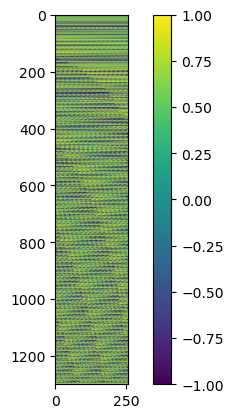

In [48]:
plt.imshow(geopos_encoder.calc_angles_and_harmonics(geopos_encoder.pool(geoloc_input).reshape(1,8,-1)).detach().numpy()[0])
plt.colorbar()

In [132]:
geopos_encoder(geoloc_input).shape

torch.Size([1, 256, 4096])

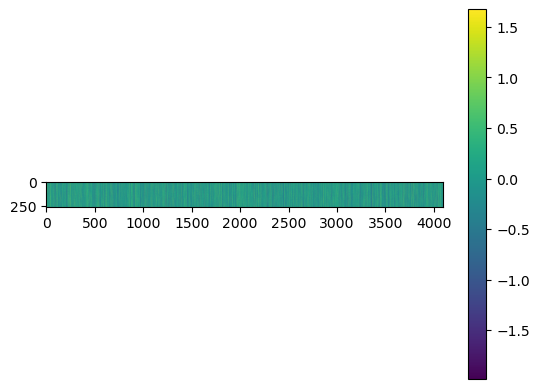

In [133]:
plt.imshow(geopos_encoder(geoloc_input).detach().numpy()[0])
plt.colorbar()

In [134]:
class_token = torch.nn.Parameter(torch.zeros(1, 1, hidden_dim))

In [135]:
image_conv(image_input).reshape(1, hidden_dim, -1).permute(0, 2, 1).shape

torch.Size([1, 256, 4096])

In [136]:
transformer_input = (
    image_conv(image_input).reshape(1, hidden_dim, -1).permute(0, 2, 1) 
    + geopos_encoder(geoloc_input)
)

In [137]:
input_shuffle = torch.randperm(transformer_input.shape[1])

In [138]:
input_shuffle

tensor([  2, 247, 195, 225,  91,  32, 104,  37, 137,  74, 177,  41, 232, 244,
        134,   1,  70, 162, 217,  80, 220,  15, 230,  62, 251, 200, 227,  19,
         21, 234, 106,  66, 249,  98, 188,  36, 192, 113,  93,  20,  33,  31,
         10, 161,  86,  78, 160,  87, 252,  60, 108, 135, 228, 121, 215,   4,
        222, 136,  12, 233, 206,  56,   9,  89, 203,  23,  65, 253,   7, 163,
        149, 139,  38, 255, 239,  92, 204,  83,  48,  51,   8, 112, 119, 223,
        172, 109,  64,  11,  22, 126, 191, 125,  39, 245, 110,  99, 173,  61,
          0, 167, 190,  17,  90, 183, 147,  29, 202, 213, 154,  95,  96,  18,
         71,  34, 114, 118,  44, 236, 140, 101, 123, 117, 159, 211, 181, 187,
        144, 127,  25, 174,  85, 219, 178, 170, 146, 193,   5, 132, 122,  59,
        201, 111, 169, 248,  77, 168, 231,  97, 216,  88,  72, 151, 145, 124,
        186, 185, 224,  94, 242, 129, 235,  27,  75, 180,  55, 184, 199, 212,
         50, 165, 158, 155,  69, 130, 240,  73, 182, 243, 116, 1

In [139]:
transformer_input = torch.cat(
    [
        class_token.expand(1, -1, -1),
        transformer_input[:, input_shuffle], 
    ],
    1
)

In [140]:
transformer_input.shape

torch.Size([1, 257, 4096])

In [141]:
from torchvision.models.vision_transformer import EncoderBlock

In [142]:
transformer_block = EncoderBlock(
    num_heads=16,
    hidden_dim=hidden_dim,
    mlp_dim=hidden_dim*4,
    dropout=0.,
    attention_dropout=0.,
)

In [143]:
transformer_block(transformer_input).shape

torch.Size([1, 257, 4096])

In [144]:
transformer_block(transformer_input)

tensor([[[-0.9129,  0.3284, -0.3185,  ..., -0.6847,  0.3870,  0.4791],
         [-0.3633,  1.3194,  0.1728,  ..., -0.3938,  1.1351,  0.2723],
         [-0.3377,  0.7375,  0.9016,  ..., -0.3642,  1.2629,  0.2562],
         ...,
         [ 0.0397,  1.1083,  1.0077,  ..., -0.2843,  0.7750,  0.3929],
         [ 0.5898,  1.3027,  0.3944,  ..., -0.9114,  1.0200,  0.5754],
         [ 0.0563,  0.9579,  0.9006,  ..., -0.4696,  0.6739,  0.5380]]],
       grad_fn=<AddBackward0>)

In [145]:
from collections import OrderedDict
from torchvision.models.vision_transformer import EncoderBlock

class Encoder(torch.nn.Module):
    """Transformer Model Encoder for sequence to sequence translation."""

    def __init__(
        self,
        seq_length: int,
        num_layers: int,
        num_heads: int,
        hidden_dim: int,
        mlp_dim: int,
        dropout: float,
        attention_dropout: float,
        norm_layer: Callable[..., torch.nn.Module] = partial(torch.nn.LayerNorm, eps=1e-6),
    ):
        super().__init__()
        # Note that batch_size is on the first dim because
        # we have batch_first=True in nn.MultiAttention() by default
        self.dropout = torch.nn.Dropout(dropout)
        layers: OrderedDict[str, torch.nn.Module] = OrderedDict()
        for i in range(num_layers):
            layers[f"encoder_layer_{i}"] = EncoderBlock(
                num_heads,
                hidden_dim,
                mlp_dim,
                dropout,
                attention_dropout,
                norm_layer,
            )
        self.layers = torch.nn.Sequential(layers)
        self.ln = norm_layer(hidden_dim)

    def forward(self, input: torch.Tensor):
        torch._assert(input.dim() == 3, f"Expected (batch_size, seq_length, hidden_dim) got {input.shape}")
        return self.ln(self.layers(self.dropout(input)))

In [146]:
vit_encoder = Encoder(257, 12, 16, 4096, 4096*4, 0., 0.)

In [147]:
x = vit_encoder(transformer_input)

In [148]:
x.shape

torch.Size([1, 257, 4096])

## Geolocation for output

We need to provide the same geolocation parameters for the output locations, passed through the same geolocation MLP network:

In [149]:
cloudsat_offset = (dt.cloudsat_unaligned.Nray.size-256)//2

In [150]:
cloudsat_unaligned = dt.cloudsat_unaligned.isel(Nray=slice(cloudsat_offset, cloudsat_offset+256))

In [151]:
cloudsat_unaligned

<xarray.DataTree 'cloudsat_unaligned'>
Group: /
    Dimensions:                                 (Nray: 256, Nbin: 125)
    Coordinates: (12/13)
        Profile_time                            (Nray) datetime64[ns] 2kB ...
        Latitude                                (Nray) float32 1kB ...
        Longitude                               (Nray) float32 1kB ...
        Range_to_intercept                      (Nray) float32 1kB ...
        DEM_elevation                           (Nray) float32 1kB ...
        x                                       (Nray) float64 2kB ...
        ...                                      ...
        Height                                  (Nray, Nbin) float32 128kB ...
        UTC_start                               timedelta64[ns] 8B ...
        TAI_start                               timedelta64[ns] 8B ...
        Vertical_binsize                        float64 8B ...
        Pitch_offset                            float64 8B ...
        Roll_offset                             float64 8B ...
    Dimensions without coordinates: Nray, Nbin
    Data variables: (12/41)
        Data_quality                            (Nray) float32 1kB ...
        Data_status                             (Nray) float32 1kB ...
        Data_targetID                           (Nray) float32 1kB ...
        RayStatus_validity                      (Nray) float32 1kB ...
        SurfaceHeightBin                        (Nray) float32 1kB ...
        SurfaceHeightBin_fraction               (Nray) float32 1kB ...
        ...                                      ...
        re_uncertainty                          (Nray, Nbin) float32 128kB ...
        IWC_uncertainty                         (Nray, Nbin) float32 128kB ...
        ice_water_path                          (Nray) float32 1kB ...
        ice_water_path_uncertainty              (Nray) float32 1kB ...
        optical_depth                           (Nray) float32 1kB ...
        optical_depth_uncertainty               (Nray) float32 1kB ...
    Attributes:
        algorithm_version:  P1_R05.4
        product_version:    P1_R05
        ID_SITE:            Cooperative Institute for Research in the Atmosphere
        ID_CREATED:         Mon Nov 30 15:46:09 2020
        ID_CENTER:          CloudSat Data Processing Center
        end_time:           20181010171741
        ID_MACHINE:         CSATLAS2
        granule_number:     66322.0
        ID_CENTER_URL:      http://cloudsat.cira.colostate.edu
        start_time:         20181010153908
        algorithm_name:     2B-GEOPROF

In [152]:
def get_sza_and_azi(date: datetime, lat: float, lon: float) -> tuple[float, float]:
    """Get the solar zenith angle at a specific time/lat/lon

    Parameters
    ----------
    date : datetime | array of datetime like
        Dates of the points
    lat : float
        Latitudes
    lon : float
        Longitudes

    Returns
    -------
    sza: float
        The solar zenith angle in degrees, where 0 is directly above, 90 is on 
        the horizon and 180 is directly below
    saa: float
        The solar azimuth angle in degrees, clockwise from North
    """
    try:
        date = pd.DatetimeIndex(date)
    except TypeError:
        date = pd.DatetimeIndex([date])
    day_of_year = date.dayofyear.to_numpy()
    hour_of_day = (
        date.hour + date.minute / 60 + date.second / 60 /60
    ).to_numpy()

    # calculate approx time equation as angle for 365 day year
    equation_of_time_approx = 2.0 * np.pi * day_of_year / 365.0

    # calculate the solar declination for the given day
    # the declination varies due to the fact that the earth rotation axis
    # is not perpendicular to the ecliptic plane
    solar_declination = (
        0.006918
        - 0.399912 * np.cos(equation_of_time_approx)
        - 0.006758 * np.cos(2.0 * equation_of_time_approx)
        - 0.002697 * np.cos(3.0 * equation_of_time_approx)
        + 0.070257 * np.sin(equation_of_time_approx)
        + 0.000907 * np.sin(2.0 * equation_of_time_approx)
        + 0.001480 * np.sin(3.0 * equation_of_time_approx)
    )

    # equation of time, used to compensate for the earth's elliptical orbit
    # around the sun and its axial tilt when calculating solar time
    # eqt is the correction in hours
    equation_of_time = 2.0 * np.pi * day_of_year / 366.0
    equation_of_time = (
        0.0072 * np.cos(equation_of_time)
        - 0.0528 * np.cos(2.0 * equation_of_time)
        - 0.0012 * np.cos(3.0 * equation_of_time)
        - 0.1229 * np.sin(equation_of_time)
        - 0.1565 * np.sin(2.0 * equation_of_time)
        - 0.0041 * np.sin(3.0 * equation_of_time)
    )

    # calculate the solar zenith angle
    omega = np.radians(
        (360.0 / 24.0) * (hour_of_day + lon / 15.0 + equation_of_time - 12.0)
    )
    sunh = np.sin(solar_declination) * np.sin(np.radians(lat)) + np.cos(
        solar_declination
    ) * np.cos(np.radians(lat)) * np.cos(omega)

    solar_elevation = np.arcsin(np.clip(sunh, -1, 1))
    solar_zenith_angle = np.pi / 2.0 - solar_elevation

    # Solar azimuth added by yaswant
    azimuth = (
        np.sin(solar_declination) * np.cos(np.radians(lat))
        - np.cos(solar_declination) * np.sin(np.radians(lat)) * np.cos(omega)
    ) / np.cos(np.pi / 2.0 - solar_zenith_angle)

    solar_azimuth_angle = np.arccos(np.clip(azimuth, -1, 1))

    return np.degrees(solar_zenith_angle), np.degrees(solar_azimuth_angle)

In [153]:
cloudsat_sza, cloudsat_azi = get_sza_and_azi(
    cloudsat_unaligned.Profile_time.values,
    cloudsat_unaligned.Latitude.values, 
    cloudsat_unaligned.Longitude.values,
)

time_of_day = (cloudsat_unaligned.Profile_time.values - cloudsat_unaligned.Profile_time.values.astype("datetime64[D]")) / np.timedelta64(1, "D").astype("timedelta64[ns]")
time_of_year = (cloudsat_unaligned.Profile_time.values - cloudsat_unaligned.Profile_time.astype("datetime64[Y]")) / np.timedelta64(1, "Y").astype("timedelta64[ns]")

geoloc_output = np.stack([
    cloudsat_unaligned.Longitude, 
    cloudsat_unaligned.Latitude, 
    np.full(cloudsat_unaligned.Longitude.shape, 0, np.float32), # 0 degree sat angle for all
    np.full(cloudsat_unaligned.Longitude.shape, 0, np.float32), # 0 degree sat angle for all
    cloudsat_azi, # need to calc solar angles
    cloudsat_sza, # need to calc solar angles
    np.full(cloudsat_unaligned.Longitude.shape, time_of_day, np.float32), 
    np.full(cloudsat_unaligned.Longitude.shape, time_of_year, np.float32), 
], 0).astype(np.float32)


# geoloc_output = np.stack([
#     np.sin(np.radians(cloudsat_unaligned.Longitude)), 
#     np.cos(np.radians(cloudsat_unaligned.Longitude)), 
#     np.sin(np.radians(cloudsat_unaligned.Latitude)), 
#     np.full(cloudsat_unaligned.Longitude.shape, np.sin(0), np.float32), # 0 degree sat angle for all
#     np.full(cloudsat_unaligned.Longitude.shape, np.cos(0), np.float32), # 0 degree sat angle for all
#     np.full(cloudsat_unaligned.Longitude.shape, np.sin(0), np.float32), # 0 degree sat angle for all
#     np.sin(np.radians(cloudsat_azi)), # need to calc solar angles
#     np.cos(np.radians(cloudsat_azi)), # need to calc solar angles
#     np.sin(np.radians(cloudsat_sza)), # need to calc solar angles
#     np.full(cloudsat_unaligned.Longitude.shape, np.sin(time_of_day), np.float32), 
#     np.full(cloudsat_unaligned.Longitude.shape, np.cos(time_of_day), np.float32), 
#     np.full(cloudsat_unaligned.Longitude.shape, np.sin(time_of_year), np.float32), 
#     np.full(cloudsat_unaligned.Longitude.shape, np.cos(time_of_year), np.float32), 
# ], -1).astype(np.float32)


In [154]:
geoloc_output.shape

(8, 256)

In [155]:
geoloc_output = torch.tensor(geoloc_output[np.newaxis])

In [156]:
geoloc_output.dtype

torch.float32

In [158]:
geopos_encoder(geoloc_output).shape

torch.Size([1, 256, 4096])

In [159]:
output_tokens = geopos_encoder(geoloc_output)

In [160]:
output_tokens.shape

torch.Size([1, 256, 4096])

In [161]:
output_shuffle = torch.randperm(output_tokens.shape[1])

In [162]:
decoder_input = torch.cat([x, output_tokens[:, output_shuffle]], 1)

In [163]:
decoder_input.shape

torch.Size([1, 513, 4096])

In [164]:
vit_decoder = Encoder(513, 4, 16, 4096, 4096*4, 0., 0.)

In [165]:
x_decode = vit_decoder(decoder_input)

In [166]:
x_decode.shape

torch.Size([1, 513, 4096])

In [167]:
output_unshuffle = torch.sort(output_shuffle).indices

In [168]:
x_decode = x_decode[:, -256:][:,output_unshuffle]

In [169]:
x_decode.shape

torch.Size([1, 256, 4096])

In [293]:
output_conv = torch.nn.Sequential(
    torch.nn.Conv1d(hidden_dim, 125, kernel_size=1, stride=1), 
)

In [294]:
x_out = output_conv(x_decode.permute(0,2,1)).permute(0,2,1)

In [295]:
x_out.shape

torch.Size([1, 256, 125])

In [296]:
x_out

tensor([[[-0.6913, -0.1722, -0.1084,  ...,  0.3221,  0.2005,  0.8164],
         [-0.6912, -0.1721, -0.1084,  ...,  0.3221,  0.2006,  0.8164],
         [-0.6911, -0.1720, -0.1084,  ...,  0.3221,  0.2006,  0.8165],
         ...,
         [-0.6698, -0.1568, -0.1147,  ...,  0.3261,  0.2129,  0.8381],
         [-0.6697, -0.1567, -0.1147,  ...,  0.3261,  0.2130,  0.8382],
         [-0.6697, -0.1566, -0.1147,  ...,  0.3262,  0.2130,  0.8383]]],
       grad_fn=<PermuteBackward0>)